In [ ]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"fadqash","key":"70379bcc0856ddd995299f35dd010744"}'}

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download -d msambare/fer2013
!unzip -q fer2013.zip

Dataset URL: https://www.kaggle.com/datasets/msambare/fer2013
License(s): DbCL-1.0
  0% 0.00/60.3M [00:00<?, ?B/s]
100% 60.3M/60.3M [00:00<00:00, 1.36GB/s]


In [ ]:
!pip install torch torchvision matplotlib pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 111.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 90.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 53.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 15.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 43.4 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling nvidia-nvjitlink-cu12-12.5.82:
      Successfully uninstalled nvidia-nvjitli

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

In [ ]:

transform = transforms.Compose([
    transforms.Grayscale(),  # Optional kalau dataset belum grayscale
    transforms.Resize((48, 48)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = ImageFolder(root='/content/train', transform=transform)
test_dataset = ImageFolder(root='/content/test', transform=transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)


In [ ]:
class CNNEmotion(nn.Module):
    def __init__(self, num_classes=7):
        super(CNNEmotion, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.BatchNorm2d(64),
            nn.MaxPool2d(kernel_size=2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.BatchNorm2d(128),
            nn.MaxPool2d(kernel_size=2),

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.BatchNorm2d(256),
            nn.MaxPool2d(kernel_size=2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 6 * 6, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CNNEmotion().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

def train(model, loader):
    model.train()
    running_loss = 0.0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    return running_loss / len(loader)


In [ ]:
def evaluate(model, loader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    return correct / total


In [ ]:
epochs = 40
for epoch in range(epochs):
    train_loss = train(model, train_loader)
    test_acc = evaluate(model, test_loader)
    print(f"Epoch {epoch+1}/{epochs}, Loss: {train_loss:.4f}, Val Acc: {test_acc:.4f}")

    if test_acc >= 0.90:
        print(f"\n🔥 Callback Triggered! Validation accuracy reached {test_acc:.4f} at epoch {epoch+1}.")
        print("💾 Saving model...")
        torch.save(model.state_dict(), 'cnn_emotion_90acc.pt')
        break


Epoch 1/40, Loss: 1.7453, Val Acc: 0.4632
Epoch 2/40, Loss: 1.3961, Val Acc: 0.4985
Epoch 3/40, Loss: 1.2625, Val Acc: 0.5343
Epoch 4/40, Loss: 1.1609, Val Acc: 0.5575
Epoch 5/40, Loss: 1.0446, Val Acc: 0.5769
Epoch 6/40, Loss: 0.9376, Val Acc: 0.5878
Epoch 7/40, Loss: 0.8293, Val Acc: 0.5901
Epoch 8/40, Loss: 0.7184, Val Acc: 0.5978
Epoch 9/40, Loss: 0.6167, Val Acc: 0.5952
Epoch 10/40, Loss: 0.5489, Val Acc: 0.6055
Epoch 11/40, Loss: 0.4649, Val Acc: 0.6007
Epoch 12/40, Loss: 0.4325, Val Acc: 0.5939
Epoch 13/40, Loss: 0.3895, Val Acc: 0.6028
Epoch 14/40, Loss: 0.3441, Val Acc: 0.6081
Epoch 15/40, Loss: 0.3344, Val Acc: 0.6002
Epoch 16/40, Loss: 0.3036, Val Acc: 0.6081
Epoch 17/40, Loss: 0.2826, Val Acc: 0.6094
Epoch 18/40, Loss: 0.2768, Val Acc: 0.6067
Epoch 19/40, Loss: 0.2629, Val Acc: 0.6034
Epoch 20/40, Loss: 0.2325, Val Acc: 0.6070
Epoch 21/40, Loss: 0.2404, Val Acc: 0.6091
Epoch 22/40, Loss: 0.2315, Val Acc: 0.6123
Epoch 23/40, Loss: 0.2163, Val Acc: 0.6067
Epoch 24/40, Loss: 0

📋 Classification Report:

              precision    recall  f1-score   support

       angry       0.49      0.52      0.51       958
     disgust       0.78      0.47      0.58       111
        fear       0.51      0.41      0.45      1024
       happy       0.82      0.80      0.81      1774
     neutral       0.54      0.56      0.55      1233
         sad       0.45      0.55      0.49      1247
    surprise       0.79      0.72      0.76       831

    accuracy                           0.61      7178
   macro avg       0.63      0.58      0.59      7178
weighted avg       0.62      0.61      0.61      7178



/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129513 (\N{JIGSAW PUZZLE PIECE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


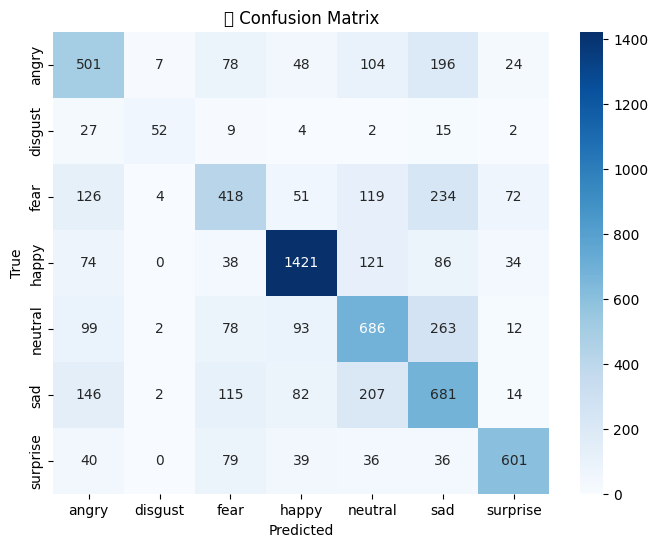

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import torch

def evaluate_model(model, dataloader, class_names):
    model.eval()
    y_true = []
    y_pred = []
    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())

    # Classification report
    print("📋 Classification Report:\n")
    print(classification_report(y_true, y_pred, target_names=class_names))

    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt="d", xticklabels=class_names, yticklabels=class_names, cmap="Blues")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title("🧩 Confusion Matrix")
    plt.show()

evaluate_model(model, test_loader, train_dataset.classes)

In [ ]:
train_losses = []
val_accuracies = []

for epoch in range(epochs):
    train_loss = train(model, train_loader)
    val_acc = evaluate(model, test_loader)

    train_losses.append(train_loss)
    val_accuracies.append(val_acc)

    print(f"Epoch {epoch+1}/{epochs}, Loss: {train_loss:.4f}, Acc: {val_acc:.4f}")

plt.figure(figsize=(12,5))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label="Training Loss", color='red')
plt.title("📉 Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(val_accuracies, label="Validation Accuracy", color='green')
plt.title("📈 Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()
plt.show()


Epoch 1/40, Loss: 0.1363, Acc: 0.6113
Epoch 2/40, Loss: 0.1196, Acc: 0.6035
Epoch 3/40, Loss: 0.1333, Acc: 0.6088
Epoch 4/40, Loss: 0.1332, Acc: 0.6085
Epoch 5/40, Loss: 0.1269, Acc: 0.6046
Epoch 6/40, Loss: 0.1322, Acc: 0.6092
Epoch 7/40, Loss: 0.1174, Acc: 0.6103
Epoch 8/40, Loss: 0.1082, Acc: 0.6042
Epoch 9/40, Loss: 0.1247, Acc: 0.6091
Epoch 10/40, Loss: 0.1189, Acc: 0.6088
Epoch 11/40, Loss: 0.1114, Acc: 0.6032
Epoch 12/40, Loss: 0.1260, Acc: 0.6017
Epoch 13/40, Loss: 0.0986, Acc: 0.6063
Epoch 14/40, Loss: 0.1065, Acc: 0.6052
Epoch 15/40, Loss: 0.1045, Acc: 0.6088
Epoch 16/40, Loss: 0.1042, Acc: 0.6024
Epoch 17/40, Loss: 0.1039, Acc: 0.6032
Epoch 18/40, Loss: 0.1040, Acc: 0.6105
Epoch 19/40, Loss: 0.1027, Acc: 0.6099
Epoch 20/40, Loss: 0.0987, Acc: 0.6031
Epoch 21/40, Loss: 0.0960, Acc: 0.6062
Epoch 22/40, Loss: 0.1167, Acc: 0.5943
Epoch 23/40, Loss: 0.1077, Acc: 0.5999
Epoch 24/40, Loss: 0.0911, Acc: 0.6007
Epoch 25/40, Loss: 0.0801, Acc: 0.5964
Epoch 26/40, Loss: 0.0869, Acc: 0.

KeyboardInterrupt: 

In [ ]:
!pip install gradio --quiet
import gradio as gr

def gradio_infer(img):
    img = img.convert("L")  # Convert to grayscale
    img = transform(img).unsqueeze(0).to(device)
    with torch.no_grad():
        output = model(img)
        pred = torch.argmax(output, dim=1).item()
    return f"🔥 Emotion: {train_dataset.classes[pred]}"


In [ ]:
gr.Interface(fn=gradio_infer,
             inputs=gr.Image(type="pil"),
             outputs="text",
             title="FER-2013 Emotion Classifier",
             description="Upload wajah 48x48 untuk deteksi emosi").launch(share=True)

In [ ]:
!pip install huggingface_hub --quiet
from huggingface_hub import login
login()

In [ ]:
import torch

# Simpan state_dict model
torch.save(model, "pytorch_model.pt")


In [ ]:
import os

model_dir = "image_emotion_model"
os.makedirs(model_dir, exist_ok=True)

# Pindahkan model
!mv pytorch_model.pt {model_dir}/pytorch_model.pt

# Buat README.md
with open(f"{model_dir}/README.md", "w") as f:
    f.write(
        "# 🧠 Image Emotion Classification - FER-2013\n"
        "This model is a simple CNN trained on the FER-2013 dataset for emotion classification.\n"
        "It predicts one of 7 emotions from a 48x48 grayscale face image.\n"
        "\n## Labels:\n"
        "- angry\n- disgust\n- fear\n- happy\n- neutral\n- sad\n- surprise"
    )

# Simpan konfigurasi model
with open(f"{model_dir}/config.json", "w") as f:
    f.write('{"input_size": [1, 48, 48], "classes": ["angry", "disgust", "fear", "happy", "neutral", "sad", "surprise"]}')


In [ ]:
from huggingface_hub import create_repo, upload_folder

# Set username kamu di bawah ini
username = "FadQ"  # Ganti dengan username Hugging Face kamu
repo_name = "image-emotion-classification-fad"

# Buat repo public (atau private=True kalau mau pribadi)
create_repo(repo_id=f"{username}/{repo_name}", private=False, exist_ok=True)



In [ ]:
from huggingface_hub import upload_folder

upload_folder(
    folder_path="image_emotion_model",        # folder yang berisi pytorch_model.bin, config.json, README.md
    repo_id=f"{username}/{repo_name}",        # pastikan kamu tulis lengkap: "username/repo"
    repo_type="model"
)


In [ ]:
from huggingface_hub import whoami
whoami()